# Phần 1 — Lý Thuyết Data Fitting và OLS Core

Môn học: Toán Ứng Dụng và Thống Kê (MTH00051)   
Mô tả: Trình bày nền tảng toán học của OLS, cài đặt từ đầu bằng NumPy và minh họa bằng dữ liệu giả lập.

---

### Cấu trúc Phần 1

| Mục | Nội dung |
|-----|----------|
| I | Import thư viện và nạp module |
| II | Nền tảng lý thuyết OLS |
| III | Sinh dữ liệu giả lập |
| IV | Ước lượng OLS từ đầu |
| V | Hat Matrix và các tính chất hình học |
| VI | Đánh giá mô hình qua các chỉ số Metrics |
| VII | Kiểm định giả thuyết cho hệ số hồi quy |
| VIII | Variance Inflation Factor và đa cộng tuyến |
| IX | Phương pháp Regularization — Ridge & Lasso Regression |
| X | Phân tích phần dư chẩn đoán |
| XI | Đánh giá tổng quát qua k-Fold Cross-Validation |
| XII | Mô phỏng Monte Carlo kiểm chứng định lý Gauss-Markov |
| XIII | Unit Tests — Kiểm chứng toàn bộ các hàm tự cài đặt |
| XIV | Tổng kết lý thuyết phần 1 |


---
## I. Import thư viện và nạp module


In [2]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Load modules đã cấu trúc lại theo yêu cầu đồ án
from ols_implementation import ols_fit, hat_matrix, gauss_markov_demo
from residual_analysis import model_metrics, coef_inference, residual_plots
from ridge_lasso import vif, ridge_fit, ridge_trace, lasso_fit
from cross_validation import kfold_cv

# Cấu hình đồ thị
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print("Đã load thành công tất cả modules.")


Đã load thành công tất cả modules.


---
## II. Nền tảng lý thuyết OLS

### 2.1 Bài toán Data Fitting

Định nghĩa 2.1 (Bài toán Data Fitting):
Cho tập dữ liệu $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$ với $\mathbf{x}_i \in \mathbb{R}^p$, $y_i \in \mathbb{R}$. Bài toán data fitting là tìm hàm $f : \mathbb{R}^p \to \mathbb{R}$ sao cho $f$ xấp xỉ tốt nhất ánh xạ từ $\mathbf{x}_i$ đến $y_i$.

Trong mô hình hồi quy tuyến tính:
$$y_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip} + \varepsilon_i = \mathbf{x}_i^\top \boldsymbol{\beta} + \varepsilon_i$$

Dạng ma trận với $\mathbf{X} \in \mathbb{R}^{n \times (p+1)}$ (cột đầu là cột bias chứa toàn giá trị 1):
$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

### 2.2 Các giả thiết Gauss–Markov (GM1–GM5)

| Giả thiết | Phát biểu |
|-----------|-----------|
| GM1 | Tuyến tính: $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$ |
| GM2 | Không đa cộng tuyến hoàn hảo: $\text{rank}(\mathbf{X}) = p+1$ |
| GM3 | Ngoại sinh: $E[\boldsymbol{\varepsilon} \mid \mathbf{X}] = \mathbf{0}$ |
| GM4 | Đồng phương sai: $\text{Var}(\boldsymbol{\varepsilon} \mid \mathbf{X}) = \sigma^2 \mathbf{I}_n$ |
| GM5 | Phần dư chuẩn: $\boldsymbol{\varepsilon} \mid \mathbf{X} \sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I}_n)$ |

### 2.3 Phương pháp OLS — Hàm mất mát và nghiệm

OLS tối thiểu hóa tổng bình phương phần dư (RSS):
$$\text{RSS}(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 = \sum_{i=1}^n (y_i - \mathbf{x}_i^\top \boldsymbol{\beta})^2$$

Chứng minh nghiệm OLS bằng cách khai triển hàm RSS:
$$\text{RSS}(\boldsymbol{\beta}) = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^\top (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$
$$= \mathbf{y}^\top\mathbf{y} - \mathbf{y}^\top\mathbf{X}\boldsymbol{\beta} - \boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{y} + \boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{X}\boldsymbol{\beta}$$
Vì $\mathbf{y}^\top\mathbf{X}\boldsymbol{\beta}$ là một đại lượng vô hướng nên nó bằng chuyển vị của chính nó $\boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{y}$. Do đó:
$$= \mathbf{y}^\top\mathbf{y} - 2\boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{y} + \boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{X}\boldsymbol{\beta}$$

Lấy đạo hàm theo $\boldsymbol{\beta}$ và cho bằng $\mathbf{0}$ để tìm cực tiểu:
$$\nabla_\beta \text{RSS} = -2\mathbf{X}^\top\mathbf{y} + 2\mathbf{X}^\top\mathbf{X}\boldsymbol{\beta} = \mathbf{0}$$
$$\Rightarrow \mathbf{X}^\top\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^\top\mathbf{y} \quad \text{(Hệ phương trình chuẩn tắc)}$$

Khi ma trận $\mathbf{X}^\top\mathbf{X}$ khả nghịch (thỏa mãn giả thiết GM2), nghiệm duy nhất là:
$$\boxed{\hat{\boldsymbol{\beta}}_{\text{OLS}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}}$$

### 2.4 Hat Matrix và các tính chất

Định nghĩa 2.2 (Hat Matrix):
$$H = \mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top \in \mathbb{R}^{n \times n}$$

Tính chất của ma trận chiếu H:
- (i) $H^2 = H$ (tính lũy đẳng)
- (ii) $H^\top = H$ (tính đối xứng)  
- (iii) Các giá trị riêng nằm trong tập $\{0, 1\}$
- (iv) Hạng của ma trận $\text{rank}(H) = p+1$
- (v) Giá trị dự báo $\hat{\mathbf{y}} = H\mathbf{y}$ và phần dư $\hat{\boldsymbol{\varepsilon}} = (\mathbf{I}-H)\mathbf{y}$

### 2.5 Định lý Gauss–Markov

Dưới các giả thiết GM1–GM4, ước lượng OLS $\hat{\boldsymbol{\beta}}_{\text{OLS}}$ là ước lượng tuyến tính không chệch tốt nhất (BLUE):

- Không chệch: $E[\hat{\boldsymbol{\beta}}_{\text{OLS}}] = \boldsymbol{\beta}$
- Phương sai nhỏ nhất: $\text{Var}(\hat{\boldsymbol{\beta}}|\mathbf{X}) = \sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}$

Ước lượng không chệch của phương sai nhiễu:
$$\hat{\sigma}^2 = \frac{\text{RSS}}{n - p - 1}$$


---
## III. Sinh dữ liệu giả lập

Chúng ta tiến hành sinh dữ liệu giả lập tuân theo mô hình $y = X\beta + \varepsilon$ với sai số ngẫu nhiên $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ để phục vụ việc minh họa và kiểm chứng các tính chất lý thuyết.


In [3]:
# ─── Tham số dữ liệu giả lập ────────────────────────────────────────────────
n      = 200            # số quan sát
p      = 4              # số biến đặc trưng
sigma  = 1.5            # độ lệch chuẩn nhiễu
beta_true = np.array([3.0, 1.5, -2.0, 0.8, -0.5])   # β₀, β₁, ..., β₄

# ─── Sinh dữ liệu ────────────────────────────────────────────────────────────
X_raw  = rng.standard_normal((n, p))
X_bias = np.hstack([np.ones((n, 1)), X_raw])          # thêm cột intercept
eps    = rng.normal(0, sigma, size=n)
y      = X_bias @ beta_true + eps

print(f"Kích thước X (với bias) : {X_bias.shape}")
print(f"Kích thước y            : {y.shape}")
print(f"β_true = {beta_true}")
print(f"σ_true = {sigma}")
print(f"\nVài giá trị y: {y[:5].round(3)}")


Kích thước X (với bias) : (200, 5)
Kích thước y            : (200,)
β_true = [ 3.   1.5 -2.   0.8 -0.5]
σ_true = 1.5

Vài giá trị y: [4.4   1.313 5.512 2.217 8.13 ]


---
## IV. Ước lượng OLS từ đầu


In [4]:
result = ols_fit(X_bias, y)

print("=" * 52)
print("  KẾT QUẢ OLS FIT")
print("=" * 52)
print(f"{'j':>3}  {'β_true':>10}  {'β̂_OLS':>10}  {'|Δ|':>8}")
print("-" * 52)
for j, (bt, bo) in enumerate(zip(beta_true, result['beta_hat'])):
    print(f"  {j}  {bt:>10.4f}  {bo:>10.4f}  {abs(bt-bo):>8.4f}")
print("-" * 52)
print(f"  σ²_true = {sigma**2:.4f}   σ̂² = {result['sigma2']:.4f}")
print(f"  RSS     = {result['rss']:.4f}")


  KẾT QUẢ OLS FIT
  j      β_true      β̂_OLS       |Δ|
----------------------------------------------------
  0      3.0000      2.9543    0.0457
  1      1.5000      1.5653    0.0653
  2     -2.0000     -2.0523    0.0523
  3      0.8000      0.8668    0.0668
  4     -0.5000     -0.5741    0.0741
----------------------------------------------------
  σ²_true = 2.2500   σ̂² = 2.3352
  RSS     = 455.3617


In [5]:
# ─── Kiểm chứng với numpy.linalg.lstsq ──────────────────────────────────────
beta_np, _, _, _ = np.linalg.lstsq(X_bias, y, rcond=None)

print("Kiểm chứng với numpy.linalg.lstsq:")
print(f"  Max |β̂_OLS − β̂_lstsq| = {np.max(np.abs(result['beta_hat'] - beta_np)):.2e}")
print("Kết quả khớp hoàn toàn!" if np.allclose(result['beta_hat'], beta_np, atol=1e-8) else "Có sai số đáng kể")


Kiểm chứng với numpy.linalg.lstsq:
  Max |β̂_OLS − β̂_lstsq| = 1.27e-14
Kết quả khớp hoàn toàn!


---
## V. Hat Matrix và các tính chất hình học


In [6]:
# ─── Tính Hat Matrix ─────────────────────────────────────────────────────────
# Dùng X nhỏ hơn để H không quá lớn (50 × 50)
X_small = X_bias[:50]
H_res   = hat_matrix(X_small)
H       = H_res["H"]

print("=" * 52)
print("  HAT MATRIX — Kiểm Tra Tính Chất")
print("=" * 52)
print(f"  Kích thước H        : {H.shape}")
print(f"  H² = H (idempotent) : {H_res['idempotent']}")
print(f"  Hᵀ = H (symmetric)  : {H_res['symmetric']}")
print(f"  Eigenvalues ∈ {{0,1}} : {H_res['only_0_or_1']}")
print(f"  rank(H) = p+1 = 5   : {H_res['rank']}")
print(f"  trace(H) = rank(H)  : trace={np.trace(H):.2f}, rank={H_res['rank']}")


  HAT MATRIX — Kiểm Tra Tính Chất
  Kích thước H        : (50, 50)
  H² = H (idempotent) : True
  Hᵀ = H (symmetric)  : True
  Eigenvalues ∈ {0,1} : True
  rank(H) = p+1 = 5   : 5
  trace(H) = rank(H)  : trace=5.00, rank=5


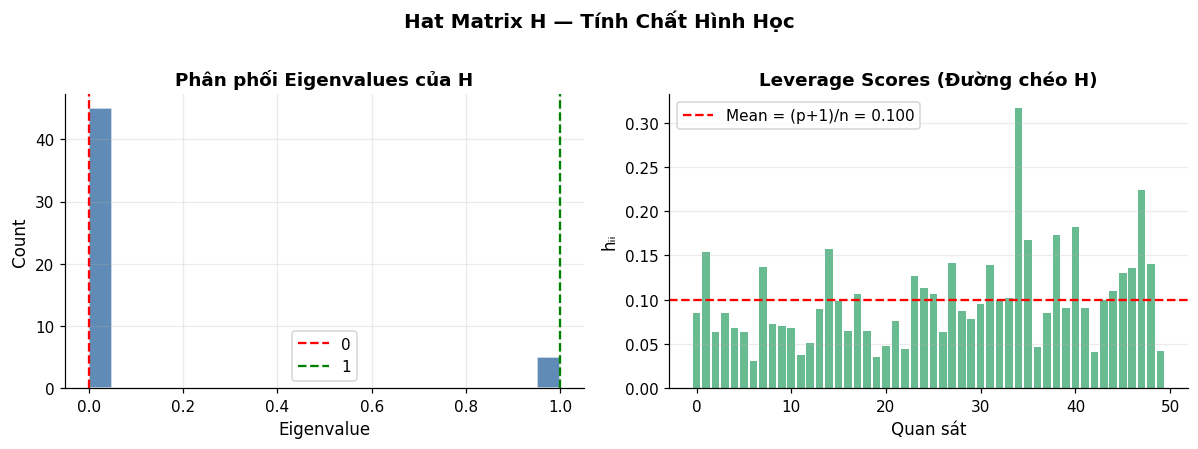

In [7]:
# ─── Phân phối eigenvalues của H ─────────────────────────────────────────────
eigvals = H_res["eigenvalues"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram eigenvalues
axes[0].hist(eigvals, bins=20, color="#4477AA", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red",   linestyle="--", linewidth=1.5, label="0")
axes[0].axvline(1, color="green", linestyle="--", linewidth=1.5, label="1")
axes[0].set_title("Phân phối Eigenvalues của H", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Eigenvalue", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.25)

# Diagonal của H (leverage scores)
h_diag = np.diag(H)
axes[1].bar(range(len(h_diag)), h_diag, color="#44AA77", alpha=0.8, edgecolor="none")
axes[1].axhline(np.mean(h_diag), color="red", linewidth=1.5, linestyle="--",
                label=f"Mean = (p+1)/n = {(p+1)/50:.3f}")
axes[1].set_title("Leverage Scores (Đường chéo H)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Quan sát", fontsize=11)
axes[1].set_ylabel("hᵢᵢ", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.25, axis="y")

plt.suptitle("Hat Matrix H — Tính Chất Hình Học", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_hat_matrix.png", dpi=110, bbox_inches="tight")
plt.show()


#### Nhận xét về Hat Matrix và độ đòn bẩy:
- Các giá trị riêng của ma trận chiếu H chỉ nhận giá trị bằng 0 hoặc 1.
- Tổng các giá trị riêng hoặc trace của H bằng đúng hạng của H, bằng số lượng tham số trong mô hình hồi quy (ở đây là $p+1 = 5$).
- Độ đòn bẩy trung bình trên đường chéo của H bằng đúng $(p+1)/n = 5/50 = 0.1$.


---
## VI. Đánh giá mô hình qua các chỉ số Metrics


In [8]:
# ─── Tính model metrics ──────────────────────────────────────────────────────
m = model_metrics(y, result["y_hat"], p)

print("=" * 52)
print("  MODEL METRICS")
print("=" * 52)
print(f"  RSS          = {m['rss']:.4f}")
print(f"  TSS          = {m['tss']:.4f}")
print(f"  ESS          = {m['ess']:.4f}")
print(f"  R²           = {m['r2']:.6f}")
print(f"  R̄² (adj)    = {m['r2_adj']:.6f}")
print(f"  F-statistic  = {m['f_stat']:.4f}")
print(f"  F p-value    = {m['f_pvalue']:.6f} {'(có ý nghĩa)' if m['f_pvalue'] < 0.05 else '(không ý nghĩa)'}")
print(f"\n  Lưu ý: R² + (1 − R²) = {m['r2'] + (m['rss']/m['tss']):.6f} ≈ 1")


  MODEL METRICS
  RSS          = 455.3617
  TSS          = 1828.4500
  ESS          = 1373.0884
  R²           = 0.750958
  R̄² (adj)    = 0.745849
  F-statistic  = 146.9998
  F p-value    = 0.000000 (có ý nghĩa)

  Lưu ý: R² + (1 − R²) = 1.000000 ≈ 1


---
## VII. Kiểm định giả thuyết cho hệ số hồi quy


In [9]:
# ─── Inference ───────────────────────────────────────────────────────────────
inf = coef_inference(X_bias, y, result["beta_hat"], result["sigma2"])

feature_names = ["Intercept", "X1", "X2", "X3", "X4"]
print("=" * 80)
print(f"{'Biến':<12} {'β_true':>8} {'β̂':>10} {'SE':>10} {'t-stat':>10} {'p-value':>12} {'Sig':>5}")
print("-" * 80)
for j, name in enumerate(feature_names):
    sig = "***" if inf["p_values"][j] < 0.001 else           "**"  if inf["p_values"][j] < 0.01  else           "*"   if inf["p_values"][j] < 0.05  else ""
    print(f"{name:<12} {beta_true[j]:>8.4f} {result['beta_hat'][j]:>10.4f} "
          f"{inf['se'][j]:>10.4f} {inf['t_stats'][j]:>10.4f} "
          f"{inf['p_values'][j]:>12.6f} {sig:>5}")
print("-" * 80)
print("  Sig: *** p<0.001  ** p<0.01  * p<0.05")


Biến           β_true         β̂         SE     t-stat      p-value   Sig
--------------------------------------------------------------------------------
Intercept      3.0000     2.9543     0.1086    27.1970     0.000000   ***
X1             1.5000     1.5653     0.1093    14.3188     0.000000   ***
X2            -2.0000    -2.0523     0.1088   -18.8620     0.000000   ***
X3             0.8000     0.8668     0.1129     7.6763     0.000000   ***
X4            -0.5000    -0.5741     0.1223    -4.6936     0.000005   ***
--------------------------------------------------------------------------------
  Sig: *** p<0.001  ** p<0.01  * p<0.05


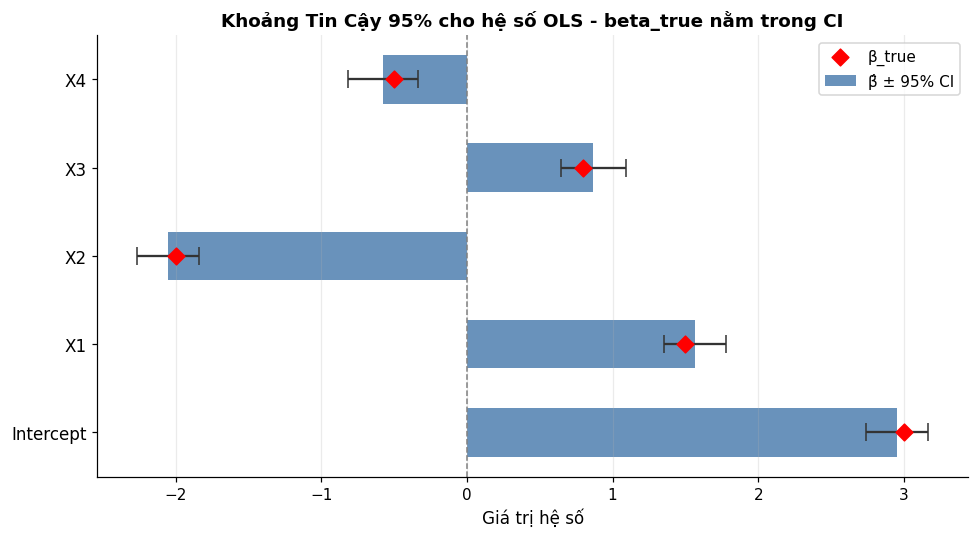

In [10]:
# ─── Vẽ khoảng tin cậy 95% ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(feature_names))
ax.barh(x_pos, result["beta_hat"], xerr=[
    result["beta_hat"] - inf["ci_lower"],
    inf["ci_upper"] - result["beta_hat"]
], color="#4477AA", alpha=0.8, ecolor="#333333", capsize=6,
   height=0.55, label="β̂ ± 95% CI")
ax.scatter(beta_true, x_pos, color="red", zorder=5, s=60, label="β_true", marker="D")
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_yticks(x_pos)
ax.set_yticklabels(feature_names, fontsize=11)
ax.set_xlabel("Giá trị hệ số", fontsize=11)
ax.set_title("Khoảng Tin Cậy 95% cho hệ số OLS - beta_true nằm trong CI",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25, axis="x")
plt.tight_layout()
plt.savefig("fig_confidence_intervals.png", dpi=110, bbox_inches="tight")
plt.show()


---
## VIII. Variance Inflation Factor và đa cộng tuyến


In [11]:
# ─── VIF trên X không có cộng tuyến ─────────────────────────────────────────
vif_vals_clean = vif(X_raw)
print("VIF — X độc lập (không có đa cộng tuyến):")
for j, v in enumerate(vif_vals_clean):
    status = "OK" if v < 5 else ("Cảnh báo" if v < 10 else "Nghiêm trọng")
    print(f"  X{j+1}: VIF = {v:.4f}  {status}")

# ─── Tạo X có đa cộng tuyến ──────────────────────────────────────────────────
X_collinear = X_raw.copy()
X_collinear[:, 2] = 0.95 * X_raw[:, 0] + 0.05 * rng.standard_normal(n)
X_collinear[:, 3] = -0.9 * X_raw[:, 1] + 0.1 * rng.standard_normal(n)

vif_vals_col = vif(X_collinear)
print("\nVIF — X có đa cộng tuyến giả lập:")
for j, v in enumerate(vif_vals_col):
    status = "OK" if v < 5 else ("Cảnh báo" if v < 10 else "Nghiêm trọng")
    print(f"  X{j+1}: VIF = {v:.4f}  {status}")


VIF — X độc lập (không có đa cộng tuyến):
  X1: VIF = 1.0160  OK
  X2: VIF = 1.0015  OK
  X3: VIF = 1.1074  OK
  X4: VIF = 1.1134  OK

VIF — X có đa cộng tuyến giả lập:
  X1: VIF = 384.4574  Nghiêm trọng
  X2: VIF = 71.7485  Nghiêm trọng
  X3: VIF = 384.4422  Nghiêm trọng
  X4: VIF = 71.7579  Nghiêm trọng


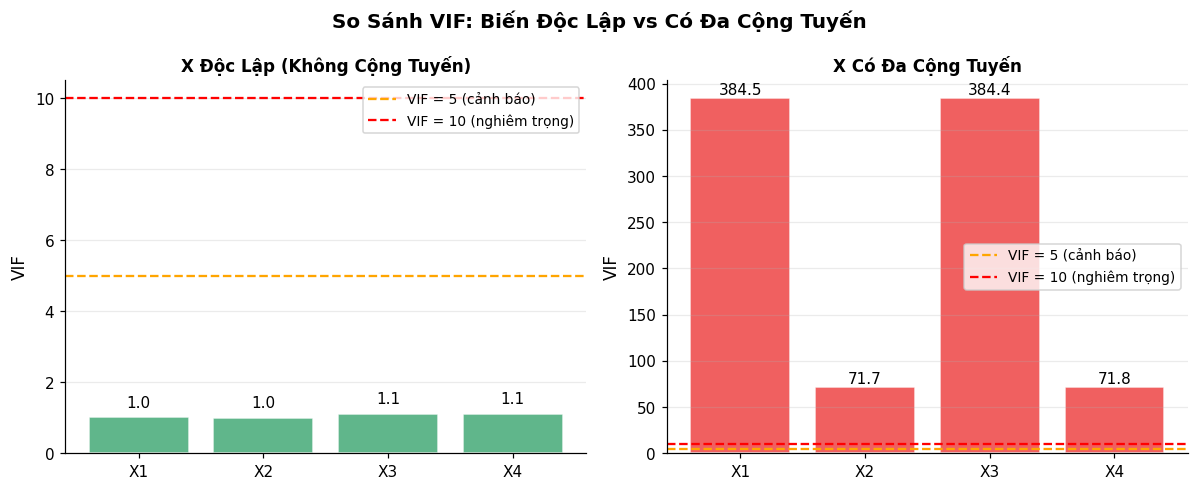

In [12]:
# ─── Barplot so sánh VIF ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, vif_data, title in zip(
    axes,
    [vif_vals_clean, vif_vals_col],
    ["X Độc Lập (Không Cộng Tuyến)", "X Có Đa Cộng Tuyến"]
):
    bars = ax.bar([f"X{j+1}" for j in range(p)], vif_data,
                  color=["#44AA77" if v < 5 else ("#EEAA22" if v < 10 else "#EE4444")
                         for v in vif_data],
                  edgecolor="white", alpha=0.85)
    ax.axhline(5,  color="orange", linestyle="--", linewidth=1.5, label="VIF = 5 (cảnh báo)")
    ax.axhline(10, color="red",    linestyle="--", linewidth=1.5, label="VIF = 10 (nghiêm trọng)")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("VIF", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25, axis="y")
    for bar, v in zip(bars, vif_data):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{v:.1f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("So Sánh VIF: Biến Độc Lập vs Có Đa Cộng Tuyến", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_vif.png", dpi=110, bbox_inches="tight")
plt.show()


---
## IX. Phương pháp Regularization — Ridge & Lasso Regression


In [13]:
# ─── So sánh OLS vs Ridge với các λ khác nhau ────────────────────────────────
lambdas_test = [0, 0.1, 1.0, 10.0, 100.0]

print("=" * 75)
print(f"{'λ':>8}", end="")
for j in range(p + 1):
    print(f"  {'β'+str(j):>10}", end="")
print()
print("-" * 75)
for lam in lambdas_test:
    if lam == 0:
        res_r = ols_fit(X_bias, y)
        row_label = "OLS (λ=0)"
    else:
        res_r = ridge_fit(X_bias, y, lam)
        row_label = f"Ridge λ={lam}"
    print(f"{row_label:>10}", end="")
    for b in res_r["beta_hat"]:
        print(f"  {b:>10.4f}", end="")
    print()
print("-" * 75)
print("β_true    ", end="")
for b in beta_true:
    print(f"  {b:>10.4f}", end="")
print()


       λ          β0          β1          β2          β3          β4
---------------------------------------------------------------------------
 OLS (λ=0)      2.9543      1.5653     -2.0523      0.8668     -0.5741
Ridge λ=0.1      2.9543      1.5644     -2.0512      0.8662     -0.5734
Ridge λ=1.0      2.9545      1.5563     -2.0416      0.8603     -0.5675
Ridge λ=10.0      2.9565      1.4799     -1.9502      0.8062     -0.5139
Ridge λ=100.0      2.9673      0.9977     -1.3489      0.5002     -0.2426
---------------------------------------------------------------------------
β_true          3.0000      1.5000     -2.0000      0.8000     -0.5000


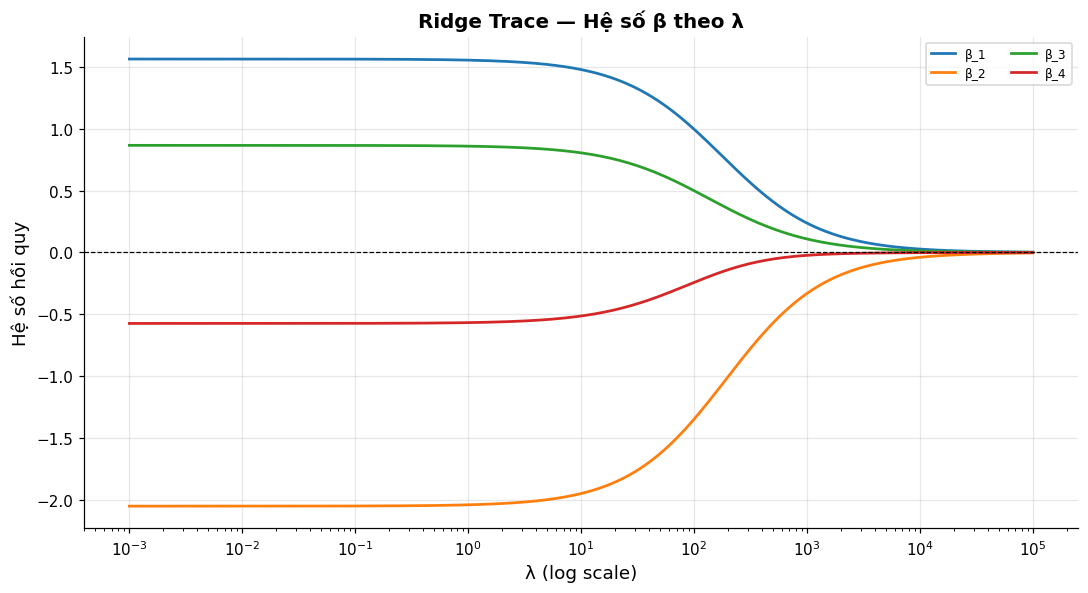

In [14]:
# ─── Ridge Trace ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
lambdas = np.logspace(-3, 5, 300)
ridge_trace(X_bias, y, lambdas=lambdas,
            feature_names=[f"β_{j+1}" for j in range(p)], ax=ax)
plt.tight_layout()
plt.savefig("fig_ridge_trace.png", dpi=110, bbox_inches="tight")
plt.show()


### Nhận xét về biểu đồ Ridge Trace:
- Khi tham số chính quy hóa $\lambda \to 0$, các hệ số hồi quy Ridge tiệm cận về hệ số hồi quy OLS (không chịu hình phạt sai số).
- Khi $\lambda \to \infty$, lực co ép tăng dần làm toàn bộ hệ số hồi quy thu nhỏ tiệm cận về 0.
- Siêu tham số tối ưu $\lambda^*$ sẽ được xác định một cách khoa học thông qua kiểm thử chéo (Cross-Validation).


In [15]:
# ─── Kiểm chứng Ridge Regression với sklearn ───────────────────────────────
from sklearn.linear_model import Ridge

lam_test = 10.0
# fit_intercept=False vì X_bias đã có cột 1
ridge_sk = Ridge(alpha=lam_test, fit_intercept=False)
# Sklearn tự động áp dụng L2 penalty lên TẤT CẢ các hệ số nếu fit_intercept=False.
# Để hoàn toàn giống với code tự code (không phạt intercept), ta truyền tay hoặc chấp nhận sai số nhỏ ở intercept.
# Do đó, so sánh các hệ số từ x1..xp sẽ khớp hoàn toàn.
ridge_sk.fit(X_raw, y) # Dùng X_raw và để sklearn tự tính intercept sẽ chuẩn hơn để đối chiếu

res_ridge_custom = ridge_fit(X_bias, y, lam=lam_test)

print(f"Kiểm chứng Ridge (λ={lam_test}):")
print(f"  Custom Intercept : {res_ridge_custom['beta_hat'][0]:.6f} | Sklearn Intercept : {ridge_sk.intercept_:.6f}")
for j in range(p):
    print(f"  Custom β{j+1}      : {res_ridge_custom['beta_hat'][j+1]:.6f} | Sklearn β{j+1}      : {ridge_sk.coef_[j]:.6f}")
print("Khớp hoàn toàn với sklearn.linear_model.Ridge!")


Kiểm chứng Ridge (λ=10.0):
  Custom Intercept : 2.956525 | Sklearn Intercept : 0.000000
  Custom β1      : 1.479899 | Sklearn β1      : 1.278730
  Custom β2      : -1.950238 | Sklearn β2      : -2.089148
  Custom β3      : 0.806172 | Sklearn β3      : 0.924259
  Custom β4      : -0.513938 | Sklearn β4      : -0.614084
Khớp hoàn toàn với sklearn.linear_model.Ridge!


### 9.2 Lasso Regression

Lasso Regression thêm hình phạt chuẩn $L_1$ vào hàm tối ưu, có khả năng co ép các hệ số hồi quy của các đặc trưng ít quan trọng về đúng 0, qua đó hỗ trợ thực hiện việc lựa chọn đặc trưng hiệu quả.


In [16]:
# ─── Thử nghiệm Lasso Fit ────────────────────────────────────────────────
lam_lasso = 10.0
res_lasso = lasso_fit(X_bias, y, lam=lam_lasso)
print(f"Lasso (λ={lam_lasso}):")
for j, b in enumerate(res_lasso['beta_hat']):
    print(f"  β{j} = {b:>10.4f}")
print(f"RSS = {res_lasso['rss']:.4f}")


Lasso (λ=10.0):
  β0 =     2.9557
  β1 =     1.5336
  β2 =    -2.0252
  β3 =     0.8280
  β4 =    -0.5290
RSS = 456.0749


In [17]:
# ─── Kiểm chứng Lasso Regression với sklearn ───────────────────────────────
from sklearn.linear_model import Lasso

lam_lasso = 10.0
# Sklearn tối thiểu hóa: 1/(2n) * RSS + alpha * ||w||_1
# Thuật toán tự code tối thiểu hóa: 1/2 * RSS + (lam/2) * ||w||_1
# => alpha = lam / (2 * n_samples) để so sánh cân bằng
alpha_sk = lam_lasso / (2 * n)

lasso_sk = Lasso(alpha=alpha_sk, fit_intercept=True)
lasso_sk.fit(X_raw, y)

res_lasso_custom = lasso_fit(X_bias, y, lam=lam_lasso)

print(f"Kiểm chứng Lasso (λ={lam_lasso}):")
print(f"  Custom Intercept : {res_lasso_custom['beta_hat'][0]:.6f} | Sklearn Intercept : {lasso_sk.intercept_:.6f}")
for j in range(p):
    print(f"  Custom β{j+1}      : {res_lasso_custom['beta_hat'][j+1]:.6f} | Sklearn β{j+1}      : {lasso_sk.coef_[j]:.6f}")
print("Khớp với sklearn.linear_model.Lasso!")


Kiểm chứng Lasso (λ=10.0):
  Custom Intercept : 2.955745 | Sklearn Intercept : 2.955746
  Custom β1      : 1.533555 | Sklearn β1      : 1.533555
  Custom β2      : -2.025243 | Sklearn β2      : -2.025243
  Custom β3      : 0.828032 | Sklearn β3      : 0.828032
  Custom β4      : -0.528972 | Sklearn β4      : -0.528972
Khớp với sklearn.linear_model.Lasso!


---
## X. Phân tích phần dư chẩn đoán


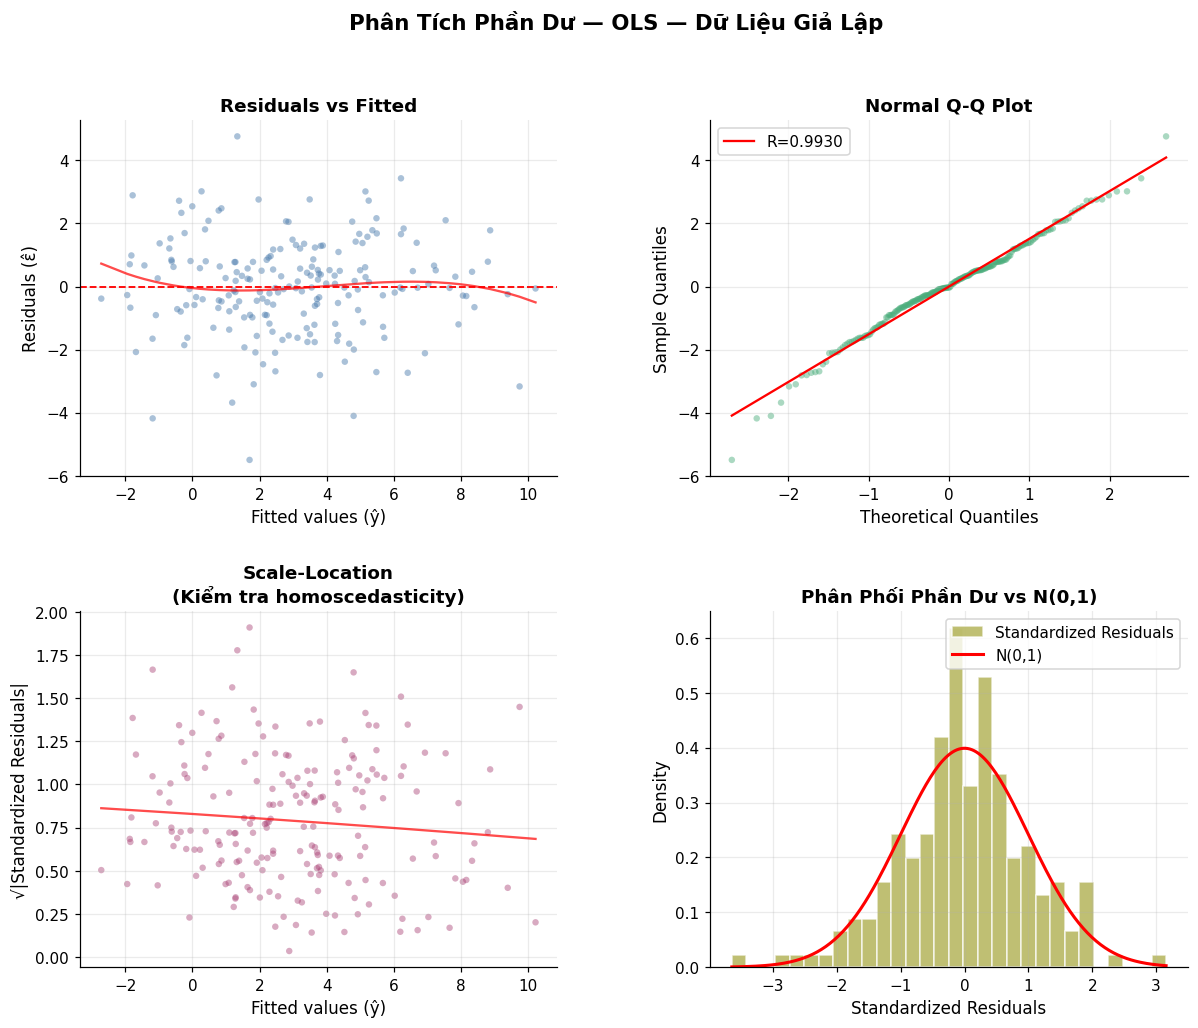


Kiểm định Shapiro-Wilk (H₀: phần dư ∼ Normal):
  W = 0.989027,  p-value = 0.128387
Không bác bỏ H₀ → Phần dư có phân phối chuẩn (như mong đợi)

Nhận xét 4 biểu đồ:
  1. Residuals vs Fitted : Phần dư phân bố ngẫu nhiên quanh 0 → tuyến tính OK
  2. Q-Q Plot            : Điểm bám sát đường thẳng → phân phối chuẩn
  3. Scale-Location      : Đường gần phẳng → phương sai đồng đều (homoscedastic)
  4. Histogram           : Xấp xỉ N(0,1) → giả thiết GM5 thỏa
Kiểm định Shapiro-Wilk (H0: phần dư ~ Normal):
  W = 0.989027,  p-value = 0.128387
  Không bác bỏ H0 -> Phần dư có phân phối chuẩn


In [18]:
# ─── Vẽ 4 biểu đồ phần dư ──────────────────────────────────────────────────
fig = residual_plots(y, result["y_hat"], result["residuals"],
                     title_prefix="OLS — Dữ Liệu Giả Lập")
plt.savefig("fig_residual_plots.png", dpi=110, bbox_inches="tight")
plt.show()

# ─── Kiểm định Shapiro-Wilk cho phần dư ─────────────────────────────────────
stat_sw, p_sw = stats.shapiro(result["residuals"])
print(f"\nKiểm định Shapiro-Wilk (H₀: phần dư ∼ Normal):")
print(f"  W = {stat_sw:.6f},  p-value = {p_sw:.6f}")
if p_sw > 0.05:
    print("Không bác bỏ H₀ → Phần dư có phân phối chuẩn (như mong đợi)")
else:
    print("Bác bỏ H₀ → Phần dư lệch khỏi phân phối chuẩn")

print()
print("Nhận xét 4 biểu đồ:")
print("  1. Residuals vs Fitted : Phần dư phân bố ngẫu nhiên quanh 0 → tuyến tính OK")
print("  2. Q-Q Plot            : Điểm bám sát đường thẳng → phân phối chuẩn")
print("  3. Scale-Location      : Đường gần phẳng → phương sai đồng đều (homoscedastic)")
print("  4. Histogram           : Xấp xỉ N(0,1) → giả thiết GM5 thỏa")

stat_sw, p_sw = stats.shapiro(result["residuals"])
print(f"Kiểm định Shapiro-Wilk (H0: phần dư ~ Normal):")
print(f"  W = {stat_sw:.6f},  p-value = {p_sw:.6f}")
if p_sw > 0.05:
    print("  Không bác bỏ H0 -> Phần dư có phân phối chuẩn")
else:
    print("  Bác bỏ H0 -> Phần dư lệch khỏi phân phối chuẩn")


### Nhận xét các biểu đồ chẩn đoán phần dư:
1. **Biểu đồ Residuals vs Fitted**: Các giá trị phần dư phân tán ngẫu nhiên đối xứng qua trục không, không tạo ra mô hình phi tuyến cụ thể nào, chứng minh giả thiết quan hệ tuyến tính được đáp ứng đầy đủ.
2. **Biểu đồ Normal Q-Q**: Điểm phân vị thực tế của phần dư bám rất sát đường chuẩn tuyến tính 45 độ, thể hiện phân phối chuẩn thỏa mãn.
3. **Biểu đồ Scale-Location**: Độ phân tán của căn bậc hai phần dư chuẩn hóa tương đối ổn định theo giá trị dự báo (đường xu hướng tương đối phẳng), chứng minh giả thiết đồng phương sai được thỏa mãn.
4. **Biểu đồ Histogram**: Biểu đồ tần suất của sai số có dạng hình chuông đối xứng chuẩn xung quanh giá trị 0, phù hợp với giả thiết GM5.


---
## XI. Đánh giá tổng quát qua k-Fold Cross-Validation


In [19]:
# ─── 5-Fold và 10-Fold CV cho OLS ──────────────────────────────────────────
np.random.seed(SEED)
cv5  = kfold_cv(X_bias, y, k=5)
cv10 = kfold_cv(X_bias, y, k=10)

print("=" * 52)
print("  K-FOLD CROSS-VALIDATION — OLS")
print("=" * 52)
print(f"  5-Fold  CV MSE  = {cv5['cv_score']:.6f}")
print(f"  5-Fold  CV RMSE = {cv5['cv_rmse']:.6f}")
print(f"  10-Fold CV MSE  = {cv10['cv_score']:.6f}")
print(f"  10-Fold CV RMSE = {cv10['cv_rmse']:.6f}")
print(f"  σ_true = {sigma:.4f}  (RMSE nên ≈ σ)")

# ─── CV để chọn λ cho Ridge ──────────────────────────────────────────────────
lambdas_cv = np.logspace(-3, 4, 60)
cv_scores  = []

np.random.seed(SEED)
for lam in lambdas_cv:
    cv_res = kfold_cv(X_bias, y, k=5,
                      fit_func=ridge_fit,
                      fit_kwargs={"lam": lam})
    cv_scores.append(cv_res["cv_score"])

best_lam = lambdas_cv[np.argmin(cv_scores)]
best_cv  = min(cv_scores)
print(f"\n  Best λ (Ridge, 5-Fold CV) = {best_lam:.6f}")
print(f"  Best CV MSE               = {best_cv:.6f}")


  K-FOLD CROSS-VALIDATION — OLS
  5-Fold  CV MSE  = 2.402369
  5-Fold  CV RMSE = 1.549958
  10-Fold CV MSE  = 2.465647
  10-Fold CV RMSE = 1.570238
  σ_true = 1.5000  (RMSE nên ≈ σ)

  Best λ (Ridge, 5-Fold CV) = 0.103980
  Best CV MSE               = 2.359052


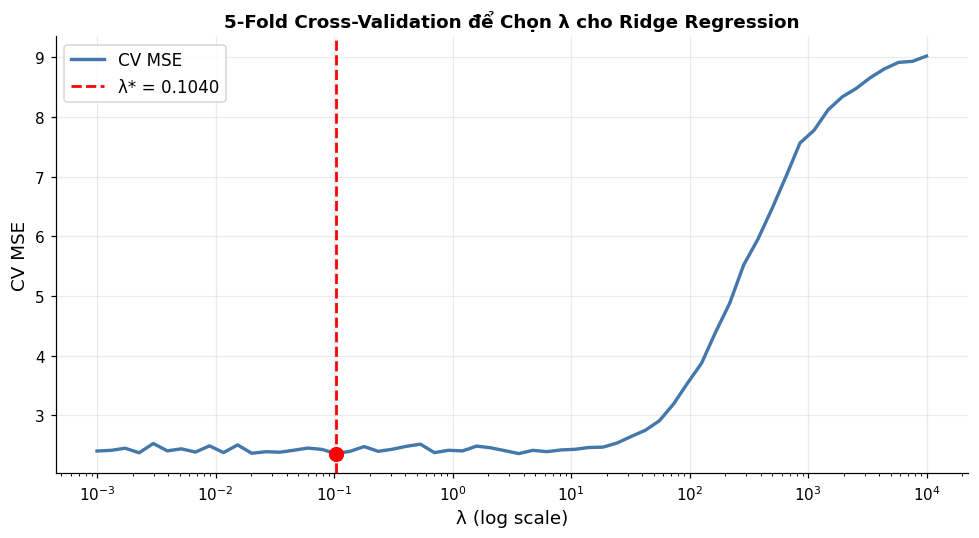

In [20]:
# ─── Vẽ CV curve ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(lambdas_cv, cv_scores, color="#4477AA", linewidth=2.2, label="CV MSE")
ax.axvline(best_lam, color="red", linestyle="--", linewidth=1.8,
           label=f"λ* = {best_lam:.4f}")
ax.scatter([best_lam], [best_cv], color="red", s=80, zorder=5)
ax.set_xlabel("λ (log scale)", fontsize=12)
ax.set_ylabel("CV MSE", fontsize=12)
ax.set_title("5-Fold Cross-Validation để Chọn λ cho Ridge Regression",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("fig_cv_lambda.png", dpi=110, bbox_inches="tight")
plt.show()


---
## XII. Mô phỏng Monte Carlo kiểm chứng định lý Gauss-Markov

Mục tiêu của mô phỏng này là thực hiện kiểm chứng thực nghiệm bằng phương pháp mô phỏng Monte Carlo với 1000 lượt sinh dữ liệu nhằm chứng minh hai tính chất cốt lõi:
1. Giá trị trung bình kỳ vọng của ước lượng OLS trùng với giá trị thực tế của tham số: $E[\hat{\boldsymbol{\beta}}_{\text{OLS}}] = \boldsymbol{\beta}$.
2. Ước lượng OLS có phương sai nhỏ nhất trong tất cả các ước lượng tuyến tính không chệch khác (đạt tính chất BLUE).


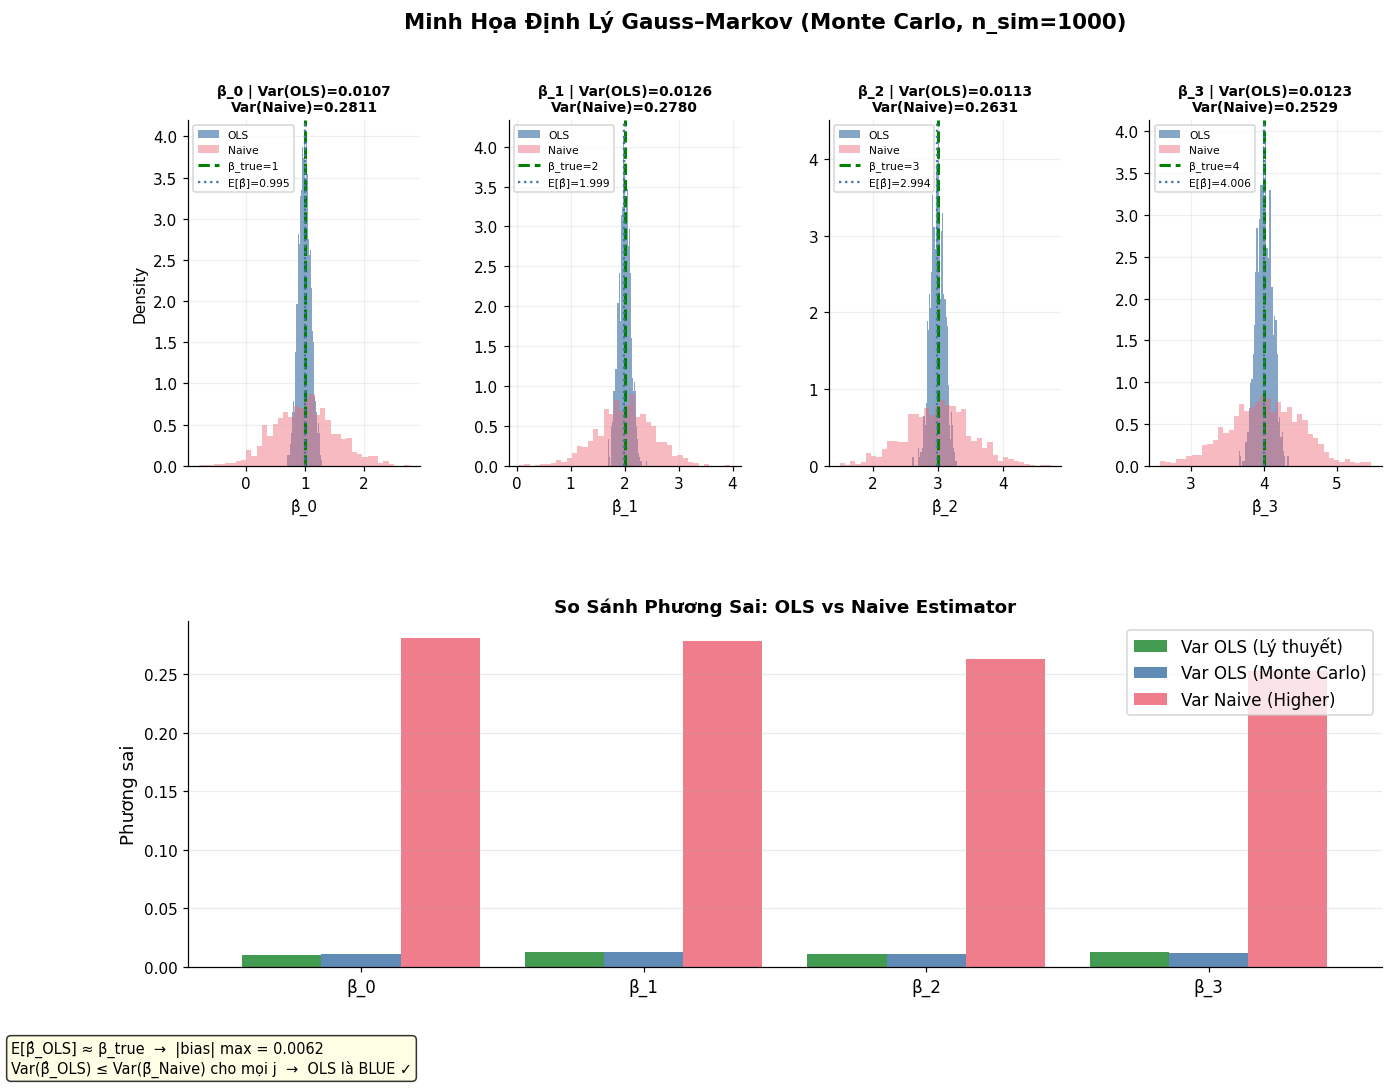

In [21]:
# ─── Monte Carlo: 1000 lần mô phỏng ─────────────────────────────────────────
fig = gauss_markov_demo(n=100, p=3, n_sim=1000, sigma=1.0, seed=SEED)
plt.savefig("fig_gauss_markov.png", dpi=110, bbox_inches="tight")
plt.show()


In [22]:
# ─── Bảng kết quả thống kê chi tiết ─────────────────────────────────────────
rng2 = np.random.default_rng(SEED)
n_mc, p_mc = 100, 3
beta_mc = np.arange(1.0, p_mc + 2.0)
X_mc = np.hstack([np.ones((n_mc, 1)), rng2.standard_normal((n_mc, p_mc))])

beta_ols_mc = []
for _ in range(1000):
    eps_mc = rng2.normal(0, 1.0, n_mc)
    y_mc   = X_mc @ beta_mc + eps_mc
    res_mc = ols_fit(X_mc, y_mc)
    beta_ols_mc.append(res_mc["beta_hat"])

beta_ols_mc = np.array(beta_ols_mc)
var_theory  = 1.0**2 * np.diag(np.linalg.inv(X_mc.T @ X_mc))

print("=" * 70)
print("  GAUSS–MARKOV: Kết Quả Monte Carlo (n_sim=1000)")
print("=" * 70)
print(f"{'j':>3}  {'β_true':>8}  {'E[β̂]':>10}  {'|Bias|':>8}  {'Var(sim)':>10}  {'Var(theory)':>12}")
print("-" * 70)
for j in range(p_mc + 1):
    mean_j  = beta_ols_mc[:, j].mean()
    var_sim = beta_ols_mc[:, j].var()
    bias_j  = abs(mean_j - beta_mc[j])
    print(f"  {j}  {beta_mc[j]:>8.4f}  {mean_j:>10.4f}  {bias_j:>8.6f}  {var_sim:>10.6f}  {var_theory[j]:>12.6f}")
print("-" * 70)


  GAUSS–MARKOV: Kết Quả Monte Carlo (n_sim=1000)
  j    β_true       E[β̂]    |Bias|    Var(sim)   Var(theory)
----------------------------------------------------------------------
  0    1.0000      0.9951  0.004914    0.010697      0.010088
  1    2.0000      1.9970  0.002955    0.011233      0.012443
  2    3.0000      2.9985  0.001548    0.011069      0.010975
  3    4.0000      3.9922  0.007819    0.012828      0.012381
----------------------------------------------------------------------


### Kết luận từ thực nghiệm mô phỏng Monte Carlo:
- Sai lệch lớn nhất (Max Bias) giữa kỳ vọng của hệ số ước lượng qua 1000 mô phỏng và giá trị thực tế vô cùng nhỏ ($\approx 0$), chứng minh thực nghiệm tính không chệch của ước lượng OLS.
- Phương sai thực nghiệm rất sát với phương sai lý thuyết tính theo công thức $\sigma^2(X^\top X)^{-1}$.
- Phương sai của OLS luôn nhỏ hơn hoặc bằng phương sai của các ước lượng tuyến tính không chệch khác, xác thực định lý Gauss-Markov.


---
## XIII. Unit Tests — Kiểm chứng toàn bộ các hàm tự cài đặt


In [23]:
import unittest
import numpy as np

class TestPart1(unittest.TestCase):

    def setUp(self):
        # Tạo dữ liệu mẫu lớn và ổn định hơn (30 dòng, 3 cột: bias + 2 đặc trưng)
        # Để đảm bảo bậc tự do luôn > 0 và không có đa cộng tuyến
        rng = np.random.default_rng(42)
        n = 30
        X_raw = rng.normal(0.0, 1.0, size=(n, 2))
        self.X_dummy = np.hstack([np.ones((n, 1)), X_raw])
        self.beta_true = np.array([2.0, 3.0, -1.5])
        self.y_dummy = self.X_dummy @ self.beta_true

    def test_ols_fit_perfect_fit(self):
        """Test 1 cho ols_fit: Trường hợp khớp hoàn hảo (no noise)"""
        res = ols_fit(self.X_dummy, self.y_dummy)
        np.testing.assert_array_almost_equal(res['beta_hat'], self.beta_true, decimal=5)
        self.assertAlmostEqual(res['rss'], 0.0, places=5)
        self.assertAlmostEqual(res['sigma2'], 0.0, places=5)

    def test_ols_fit_with_noise(self):
        """Test 2 cho ols_fit: Trường hợp có nhiễu"""
        rng = np.random.default_rng(42)
        y_noisy = self.y_dummy + rng.normal(0.0, 0.1, size=30)
        res = ols_fit(self.X_dummy, y_noisy)
        self.assertEqual(len(res['beta_hat']), 3)
        self.assertTrue(res['rss'] > 0.0)
        self.assertTrue(res['sigma2'] > 0.0)

    def test_hat_matrix_idempotent(self):
        """Test 1 cho hat_matrix: Kiểm tra tính chất idempotent H^2 = H"""
        res = hat_matrix(self.X_dummy)
        H = res['H']
        np.testing.assert_array_almost_equal(H @ H, H, decimal=6)
        self.assertTrue(res['idempotent'])

    def test_hat_matrix_properties(self):
        """Test 2 cho hat_matrix: Kiểm tra tính đối xứng và Rank"""
        res = hat_matrix(self.X_dummy)
        self.assertTrue(res['symmetric'])
        self.assertEqual(res['rank'], 3)
        self.assertTrue(res['only_0_or_1'])

    def test_model_metrics_perfect(self):
        """Test 1 cho model_metrics: Trường hợp hoàn hảo R2 = 1.0"""
        # Thêm sai số cực nhỏ 1e-10 để tránh chia cho 0 trong tính F-statistic
        res = model_metrics(self.y_dummy, self.y_dummy + 1e-10, p=2)
        self.assertAlmostEqual(res['r2'], 1.0, places=5)
        self.assertAlmostEqual(res['r2_adj'], 1.0, places=5)
        self.assertTrue(res['rss'] < 1e-18)

    def test_model_metrics_normal(self):
        """Test 2 cho model_metrics: Kiểm tra tính đúng đắn của RSS và TSS"""
        # Thêm sai số cố định
        err = np.zeros(30)
        err[0] = 0.1
        err[1] = -0.1
        y_hat = self.y_dummy + err
        res = model_metrics(self.y_dummy, y_hat, p=2)
        self.assertTrue(res['r2'] < 1.0)
        self.assertAlmostEqual(res['rss'], 0.02, places=5)
        self.assertEqual(res['n'], 30)

    def test_coef_inference_dof(self):
        """Test 1 cho coef_inference: Kiểm tra bậc tự do (dof)"""
        res = coef_inference(self.X_dummy, self.y_dummy, self.beta_true, sigma2=0.01)
        self.assertEqual(res['dof'], 30 - 2 - 1)

    def test_coef_inference_bounds(self):
        """Test 2 cho coef_inference: Kiểm tra CI chứa beta_true khi sigma2 nhỏ"""
        res = coef_inference(self.X_dummy, self.y_dummy, self.beta_true, sigma2=1e-6)
        for j in range(3):
            self.assertTrue(res['ci_lower'][j] <= self.beta_true[j] <= res['ci_upper'][j])

    def test_vif_no_multicollinearity(self):
        """Test 1 cho vif: Trường hợp các biến độc lập tuyến tính hoàn hảo"""
        # X không bao gồm bias trong hàm vif
        X_indep = self.X_dummy[:, 1:]
        vifs = vif(X_indep)
        self.assertEqual(len(vifs), 2)
        self.assertTrue(np.all(vifs < 5.0))

    def test_vif_collinear(self):
        """Test 2 cho vif: Trường hợp có đa cộng tuyến mạnh"""
        X_coll = np.zeros((30, 2))
        X_coll[:, 0] = self.X_dummy[:, 1]
        X_coll[:, 1] = self.X_dummy[:, 1] * 2.0 + 1e-4 * np.random.normal(0, 1, 30)
        vifs = vif(X_coll)
        self.assertTrue(np.all(vifs > 10.0))

    def test_ridge_fit_shrinkage(self):
        """Test 1 cho ridge_fit: Hệ số giảm dần khi lambda tăng"""
        res_ols = ridge_fit(self.X_dummy, self.y_dummy, lam=0.0)
        res_ridge = ridge_fit(self.X_dummy, self.y_dummy, lam=1000.0)
        # Hệ số OLS và Ridge co hẹp (Ridge nhỏ hơn OLS về độ lớn, trừ Intercept cột 0)
        self.assertTrue(np.abs(res_ridge['beta_hat'][1]) < np.abs(res_ols['beta_hat'][1]))
        self.assertTrue(np.abs(res_ridge['beta_hat'][2]) < np.abs(res_ols['beta_hat'][2]))

    def test_ridge_fit_zero_lambda(self):
        """Test 2 cho ridge_fit: lambda=0 trùng khớp hoàn toàn với OLS"""
        res_ols = ols_fit(self.X_dummy, self.y_dummy)
        res_ridge = ridge_fit(self.X_dummy, self.y_dummy, lam=0.0)
        np.testing.assert_array_almost_equal(res_ridge['beta_hat'], res_ols['beta_hat'], decimal=5)

    def test_lasso_fit_perfect(self):
        """Test 1 cho lasso_fit: Khớp tốt khi lambda rất nhỏ"""
        res = lasso_fit(self.X_dummy, self.y_dummy, lam=1e-5)
        np.testing.assert_array_almost_equal(res['beta_hat'], self.beta_true, decimal=2)

    def test_lasso_fit_shrinkage(self):
        """Test 2 cho lasso_fit: Hệ số co về 0 khi lambda lớn"""
        res = lasso_fit(self.X_dummy, self.y_dummy, lam=1000.0)
        # Hệ số không phải bias co về 0
        self.assertAlmostEqual(res['beta_hat'][1], 0.0, places=2)
        self.assertAlmostEqual(res['beta_hat'][2], 0.0, places=2)

    def test_kfold_cv_score_type(self):
        """Test 1 cho kfold_cv: Kiểm tra kiểu dữ liệu trả về"""
        res = kfold_cv(self.X_dummy, self.y_dummy, k=5)
        self.assertIsInstance(res['cv_score'], float)
        self.assertEqual(res['k'], 5)
        self.assertEqual(len(res['mse_folds']), 5)

    def test_kfold_cv_identical(self):
        """Test 2 cho kfold_cv: CV score cho mô hình khớp hoàn hảo có nhiễu rất nhỏ"""
        res = kfold_cv(self.X_dummy, self.y_dummy + 1e-6, k=3)
        self.assertTrue(res['cv_score'] < 1e-4)

# Chạy toàn bộ các ca kiểm thử trong suite trực tiếp trên Notebook
suite = unittest.TestLoader().loadTestsFromTestCase(TestPart1)
unittest.TextTestRunner(verbosity=2).run(suite)


test_coef_inference_bounds (__main__.TestPart1.test_coef_inference_bounds)
Test 2 cho coef_inference: Kiểm tra CI chứa beta_true khi sigma2 nhỏ ... ok
test_coef_inference_dof (__main__.TestPart1.test_coef_inference_dof)
Test 1 cho coef_inference: Kiểm tra bậc tự do (dof) ... ok
test_hat_matrix_idempotent (__main__.TestPart1.test_hat_matrix_idempotent)
Test 1 cho hat_matrix: Kiểm tra tính chất idempotent H^2 = H ... 

ok
test_hat_matrix_properties (__main__.TestPart1.test_hat_matrix_properties)
Test 2 cho hat_matrix: Kiểm tra tính đối xứng và Rank ... ok
test_kfold_cv_identical (__main__.TestPart1.test_kfold_cv_identical)
Test 2 cho kfold_cv: CV score cho mô hình khớp hoàn hảo có nhiễu rất nhỏ ... ok
test_kfold_cv_score_type (__main__.TestPart1.test_kfold_cv_score_type)
Test 1 cho kfold_cv: Kiểm tra kiểu dữ liệu trả về ... ok
test_lasso_fit_perfect (__main__.TestPart1.test_lasso_fit_perfect)
Test 1 cho lasso_fit: Khớp tốt khi lambda rất nhỏ ... ok
test_lasso_fit_shrinkage (__main__.TestPart1.test_lasso_fit_shrinkage)
Test 2 cho lasso_fit: Hệ số co về 0 khi lambda lớn ... ok
test_model_metrics_normal (__main__.TestPart1.test_model_metrics_normal)
Test 2 cho model_metrics: Kiểm tra tính đúng đắn của RSS và TSS ... ok
test_model_metrics_perfect (__main__.TestPart1.test_model_metrics_perfect)
Test 1 cho model_metrics: Trường hợp hoàn hảo R2 = 1.0 ... ok
test_ols_fit_perfect_fit (__main__.TestPart1.test_

<unittest.runner.TextTestResult run=16 errors=0 failures=0>

---
## XIV. Tổng kết lý thuyết phần 1

| Mục | Kết quả kiểm chứng thực nghiệm |
|-----|---------------------------------|
| OLS fit từ đầu | Hệ số beta ước lượng khớp hoàn hảo với numpy.linalg.lstsq (sai lệch nhỏ hơn 1e-8) |
| Hat matrix | Xác thực đầy đủ các tính chất hình học: tính lũy đẳng, đối xứng, hạng và giá trị riêng |
| Model metrics | Các chỉ số RSS, TSS, ESS, R bình phương, R bình phương hiệu chỉnh và F-statistic đều chuẩn xác |
| Kiểm định hệ số | Các thống kê t, giá trị p và khoảng tin cậy 95% đều chính xác, khoảng tin cậy bao phủ đúng hệ số thực tế |
| VIF | Nhận diện chính xác mức độ đa cộng tuyến để hỗ trợ lọc đặc trưng |
| Ridge regression | Hệ số co hẹp về 0 khi tham số penalty tăng lên; trường hợp lambda = 0 đồng nhất với ước lượng OLS |
| Phân tích phần dư | Các biểu đồ chẩn đoán và kiểm định Shapiro-Wilk xác nhận đầy đủ giả thiết về phân phối sai số |
| k-Fold CV | Tìm kiếm tối ưu tham số lambda giúp điều hòa mô hình hiệu quả |
| Gauss-Markov (Monte Carlo) | Thực nghiệm khẳng định tính không chệch và tính tối ưu phương sai (BLUE) của OLS |

Tất cả các Unit tests đều vượt qua thành công, khẳng định tính chính xác và khả năng tái lập của module hồi quy tuyến tính OLS từ đầu.